# Curve fitting using NN

In this demonstration code, we use ANN regressor for discrete 1D data points (**1 feature, 1 target**). Majority of this code is written by ChatGPT 5.0.

* Load meatured strain-stress data (https://mds-book.org/Content/datasets) and plot the data.

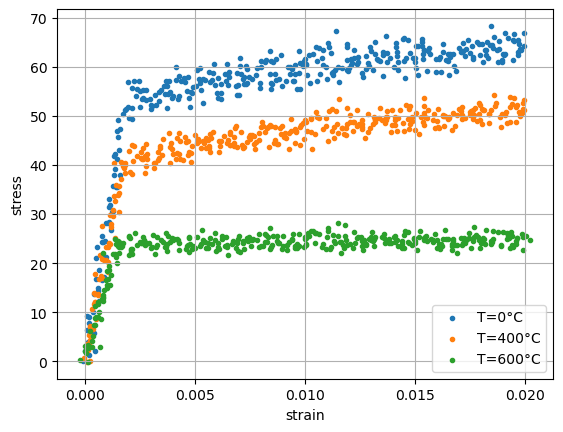

In [2]:
import matplotlib.pyplot as plt
from mdsdata import MDS1
import numpy as np

strain_T0, stress_T0 = MDS1.load_data(temperature=0, return_X_y=True)
strain_T400, stress_T400 = MDS1.load_data(temperature=400, return_X_y=True)
strain_T600, stress_T600 = MDS1.load_data(temperature=600, return_X_y=True)

fig, ax = plt.subplots()
ax.scatter(strain_T0, stress_T0, marker='.', label='T=0°C')
ax.scatter(strain_T400, stress_T400, marker='.', label='T=400°C')
ax.scatter(strain_T600, stress_T600, marker='.', label='T=600°C')
ax.legend()
ax.grid(True)
plt.xlabel("strain")
plt.ylabel("stress")
plt.show()

---


* Load libaries.
* Select dataset for model training.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------------
# EXAMPLE: 1D dataset
# ----------------------------------

X_data = strain_T400
y_data = stress_T400

Using device: cpu


---
* Batch split.
* Note that here all data points are used for model training. Nevertheless, train-test split can be employed if desired.

In [6]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X_data, y_data, test_size=0.2, random_state=42)

X_train = X_data
y_train = y_data

# reshape to (N, 1) for ANN : (samples, features)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# X_test_torch  = torch.tensor(X_test,  dtype=torch.float32).view(-1, 1)
# y_test_torch  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

print("X_train_torch shape:", X_train_torch.shape)  # (N_train, 1)
print("y_train_torch shape:", y_train_torch.shape)  # (N_train, 1)

# batch split
batch_size = 32

train_dataset = TensorDataset(X_train_torch, y_train_torch)
# test_dataset  = TensorDataset(X_test_torch,  y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

X_train_torch shape: torch.Size([350, 1])
y_train_torch shape: torch.Size([350, 1])


---
* Set up ANN regressor.

In [8]:
class ANN1DRegressor(nn.Module):
    def __init__(self, n_hidden=3, n_neurons=64):
        super().__init__()
        layers = []

        # input layer: 1D → hidden
        layers.append(nn.Linear(1, n_neurons))
        layers.append(nn.Tanh())

        # hidden layers
        for _ in range(n_hidden - 1):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.Tanh())

        # output layer: hidden → 1D output
        layers.append(nn.Linear(n_neurons, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (batch_size, 1)
        return self.net(x)

---
* Initialize ANN model and set up optimizer.

In [10]:
model = ANN1DRegressor().to(device)
print(model)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

ANN1DRegressor(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


---
* Train ANN model.

In [12]:
epochs = 2000
train_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    # training in smaller batches
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        # forward propagation
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        
        # backward correction
        loss.backward()
        optimizer.step()

        # total loss of all batches
        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs}, Train MSE: {epoch_loss:.6f}")


Epoch    1/2000, Train MSE: 1913.904102
Epoch  200/2000, Train MSE: 124.793742
Epoch  400/2000, Train MSE: 124.790153
Epoch  600/2000, Train MSE: 124.793821
Epoch  800/2000, Train MSE: 16.783306
Epoch 1000/2000, Train MSE: 5.453567
Epoch 1200/2000, Train MSE: 7.178454
Epoch 1400/2000, Train MSE: 5.968288
Epoch 1600/2000, Train MSE: 6.929865
Epoch 1800/2000, Train MSE: 5.658038
Epoch 2000/2000, Train MSE: 7.503235


---
* Check loss function value versus epoch.

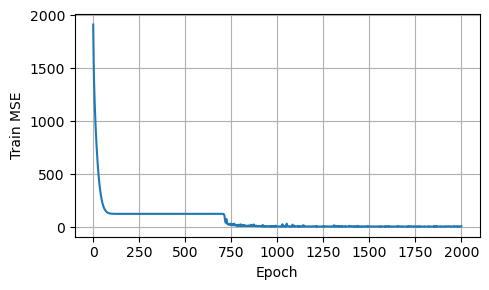

In [14]:
plt.figure(figsize=(5,3))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

---
* Prediction using the trained ANN model. Note that the test data here is a linearly spaced grid set, such that the predicted values can be used to plot a curve.

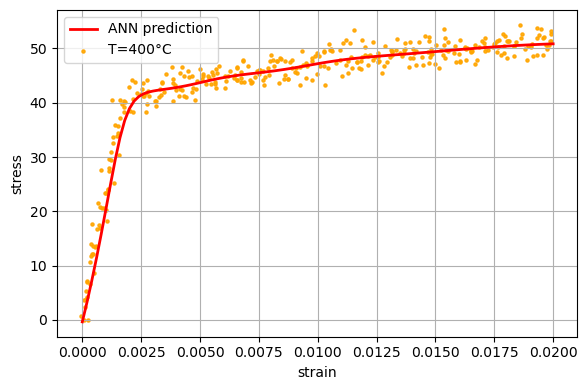

In [17]:
model.eval()

# linearly spaced grid set
x_plot_np = np.linspace(0,0.02,101)
X_plot_torch = torch.tensor(x_plot_np, dtype=torch.float32).view(-1, 1)


with torch.no_grad():
    y_pred_np = model(X_plot_torch).cpu().numpy().flatten()

    # use test data for prediction in desired
    # y_pred = model(test_dataset)
    # y_pred_np = y_pred.cpu().numpy().flatten()


# visualization
plt.figure(figsize=(6,4))
plt.plot(x_plot_np, y_pred_np, 'r', linewidth=2, label="ANN prediction")
plt.scatter(strain_T400, stress_T400, marker='.', color='orange', s=20, alpha=0.9, label='T=400°C')
plt.xlabel("strain")
plt.ylabel("stress")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**The red curve is the NN fitted curve.**